## 1. Setup and Imports 

In [8]:
# Other libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import joblib
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


In [9]:
# Our own libraries
from models.augment_dataset import select_cryptomining_like_traffic, add_realistic_noise, augment_with_feature_correlation, map_nids_to_features, get_feature_columns
from models.data_preprocessor import download_unsw_nb15_dataset, load_cn21_dataset

In [ ]:
# Download dataset and set root directory
print("\n[1/2] Checking UNSW-NB15 dataset...")
download_unsw_nb15_dataset()

current_path = Path(os.getcwd())


[1/2] Checking UNSW-NB15 dataset...
UNSW-NB15 dataset already downloaded


## 2. Load & Process CNT21 Dataset

In [4]:
print("\n[2/2] Processing CN21 dataset...")
dataset_root = current_path / 'dataset'
cn21_df = load_cn21_dataset(dataset_root)
output_path = dataset_root / 'cn21_processed.csv'
cn21_df.to_csv(output_path, index=False)
print(f"Loaded {len(cn21_df)} flows: {(cn21_df['label']==0).sum()} benign, {(cn21_df['label']==1).sum()} malicious")
print(f"Saved to: {output_path}")

print("\n" + "=" * 70)
print("✓ Preprocessing complete")
print("=" * 70)
print("\nNext steps:")
print("  python3 models/augment_dataset.py")
print("  python3 train_models.py --augmented")


[2/2] Processing CN21 dataset...
Loaded 54 flows: 18 benign, 36 malicious
Loaded 54 flows: 18 benign, 36 malicious
Saved to: c:\.School\NYU\AIN\Astra\dataset\cn21_processed.csv

✓ Preprocessing complete

Next steps:
  python3 models/augment_dataset.py
  python3 train_models.py --augmented


## 3. Augment Dataset with Noisy Data

In [5]:
def add_noisy_data():
    print("=" * 70)
    print("DATA AUGMENTATION - MODEL-GUIDED SELECTION")
    print("=" * 70)
    
    dataset_path = Path('dataset/cn21_processed.csv')
    if not dataset_path.exists():
        print("Error: Run 'python3 models/data_preprocessor.py' first")
        return
    
    df = pd.read_csv(dataset_path)
    print(f"CN21: {len(df)} flows ({(df['label']==0).sum()} benign, {(df['label']==1).sum()} malicious)")
    
    augmented_noise = add_realistic_noise(df, n_augmented_per_sample=5, noise_level=0.15)
    augmented_dist = augment_with_feature_correlation(df, n_samples=300)
    combined = pd.concat([augmented_noise, augmented_dist], ignore_index=True)
    
    print(f"Noise augmentation: {len(combined)} flows")

    return combined
    
    

noisy_data = add_noisy_data()

DATA AUGMENTATION - MODEL-GUIDED SELECTION
CN21: 54 flows (18 benign, 36 malicious)
Noise augmentation: 624 flows


## 4. Augment Dataset with Cryptomining-like Data from UNSW-NB15

In [6]:
def add_nids_data(noisy_data):
  nids_data = select_cryptomining_like_traffic(confidence_threshold=0.6)
  if nids_data:
      stats = nids_data['stats']
      print(f"\nNIDS selection (threshold=0.6, both models agree):")
      print(f"  Examined: {stats['total_botnet']} botnet flows")
      print(f"  Selected: {stats['selected']} cryptomining-like ({stats['selected']/stats['total_botnet']*100:.2f}%)")
      print(f"  RF confidence: {stats['rf_avg_conf']:.3f}, SVM confidence: {stats['svm_avg_conf']:.3f}")
      
      crypto_like = nids_data['cryptomining_like']
      benign_nids = nids_data['benign']
      
      crypto_sample = crypto_like.sample(min(len(crypto_like), 680), random_state=42)
      benign_sample = benign_nids.sample(min(1500, len(benign_nids)), random_state=42)
      
      crypto_mapped = map_nids_to_features(crypto_sample, label_value=1)
      crypto_mapped['source_id'] = [f'nids_crypto_{i}' for i in range(len(crypto_mapped))]
      
      benign_mapped = map_nids_to_features(benign_sample, label_value=0)
      benign_mapped['source_id'] = [f'nids_benign_{i}' for i in range(len(benign_mapped))]
      
      print(f"Added: {len(crypto_mapped)} crypto-like, {len(benign_mapped)} benign")
      
      combined = pd.concat([noisy_data, crypto_mapped, benign_mapped], ignore_index=True)
  feature_cols = get_feature_columns()
  feature_cols = [f for f in feature_cols if f in combined.columns]
  final_cols = ['source_id'] + feature_cols + ['label']
  combined = combined[final_cols]
  
  print(f"\nTotal: {len(combined)} flows ({(combined['label']==0).sum()} benign, {(combined['label']==1).sum()} malicious)")
  
  output_path = Path('dataset/cn21_augmented.csv')
  combined.to_csv(output_path, index=False)
  print(f"✓ Saved: {output_path}")

  return combined

df = add_nids_data(noisy_data)


NIDS selection (threshold=0.6, both models agree):
  Examined: 61374 botnet flows
  Selected: 680 cryptomining-like (1.11%)
  RF confidence: 0.689, SVM confidence: 0.801
Added: 680 crypto-like, 1500 benign

Total: 2804 flows (1758 benign, 1046 malicious)
✓ Saved: dataset\cn21_augmented.csv


## 5. Visualize Data

Class distribution:
label
0    1758
1    1046
Name: count, dtype: int64

Crypto: 1046, Non-crypto: 1758


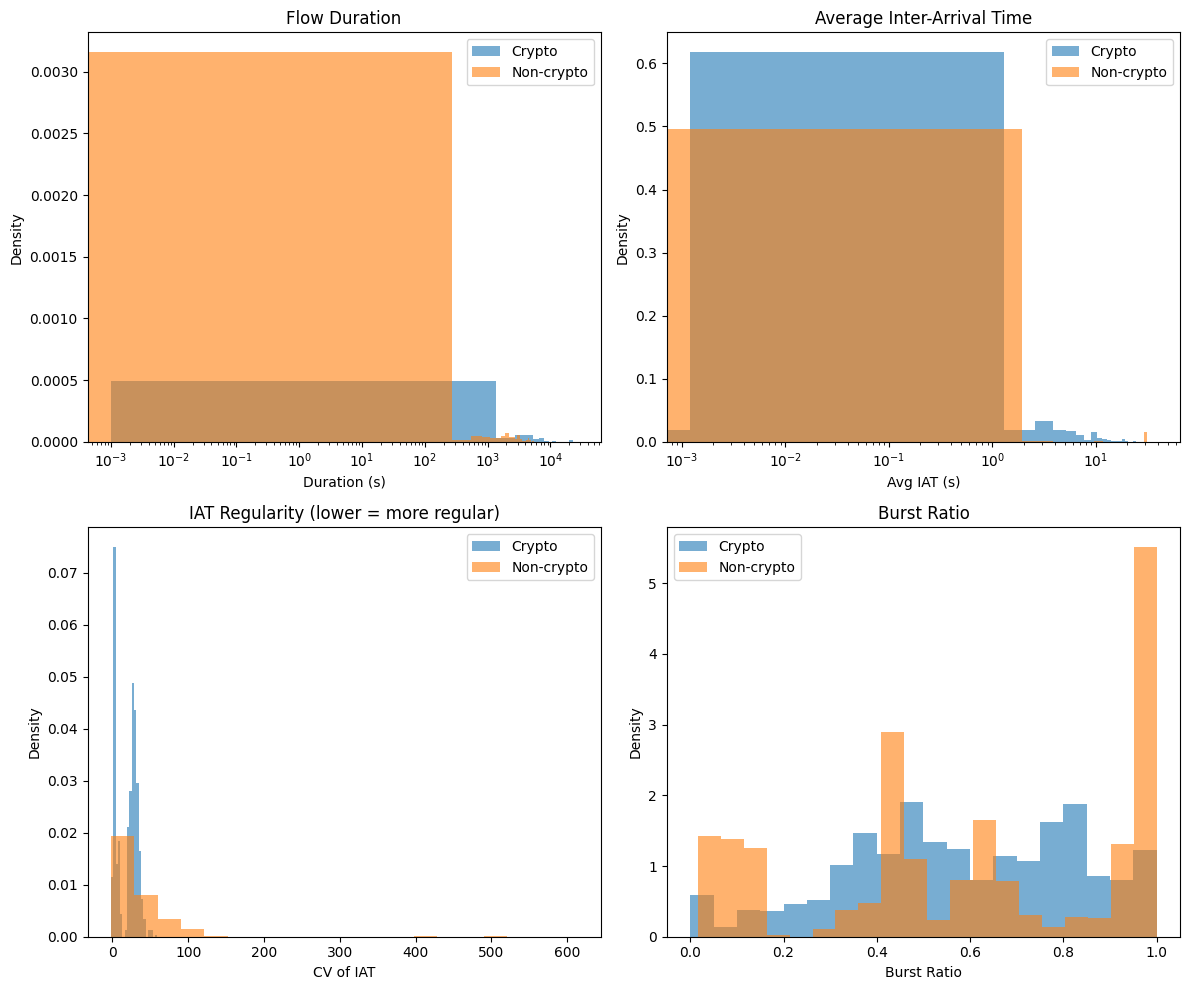

In [10]:
# Class distribution
print("Class distribution:")
print(df['label'].value_counts())
print(f"\nCrypto: {df['label'].sum()}, Non-crypto: {(df['label']==0).sum()}")

# Visualize key features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Duration
axes[0, 0].hist(df[df['label']==1]['duration'], bins=20, alpha=0.6, label='Crypto', density=True)
axes[0, 0].hist(df[df['label']==0]['duration'], bins=20, alpha=0.6, label='Non-crypto', density=True)
axes[0, 0].set_xlabel('Duration (s)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Flow Duration')
axes[0, 0].legend()
axes[0, 0].set_xscale('log')

# Average IAT
axes[0, 1].hist(df[df['label']==1]['avg_iat'], bins=20, alpha=0.6, label='Crypto', density=True)
axes[0, 1].hist(df[df['label']==0]['avg_iat'], bins=20, alpha=0.6, label='Non-crypto', density=True)
axes[0, 1].set_xlabel('Avg IAT (s)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Average Inter-Arrival Time')
axes[0, 1].legend()
axes[0, 1].set_xscale('log')

# CV of IAT (regularity measure)
axes[1, 0].hist(df[df['label']==1]['cv_iat'], bins=20, alpha=0.6, label='Crypto', density=True)
axes[1, 0].hist(df[df['label']==0]['cv_iat'], bins=20, alpha=0.6, label='Non-crypto', density=True)
axes[1, 0].set_xlabel('CV of IAT')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('IAT Regularity (lower = more regular)')
axes[1, 0].legend()

# Burst ratio
axes[1, 1].hist(df[df['label']==1]['burst_ratio'], bins=20, alpha=0.6, label='Crypto', density=True)
axes[1, 1].hist(df[df['label']==0]['burst_ratio'], bins=20, alpha=0.6, label='Non-crypto', density=True)
axes[1, 1].set_xlabel('Burst Ratio')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Burst Ratio')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 6. Load Finalized Data and Final Processing

In [11]:
data_path = Path('dataset/cn21_augmented.csv')
if not data_path.exists():
        print("Error: Augmented dataset not found")
        

df = pd.read_csv(data_path)
feature_cols = ['duration', 'total_packets', 'total_bytes', 'avg_packet_size', 
                    'std_packet_size', 'avg_iat', 'std_iat', 'cv_iat', 'burst_ratio', 
                    'small_packet_ratio', 'large_packet_ratio', 'packet_rate', 'byte_rate']
    
unique_sources = df['source_id'].unique()
np.random.seed(42)
np.random.shuffle(unique_sources)

split_idx = int(len(unique_sources) * 0.8)
train_sources = unique_sources[:split_idx]
test_sources = unique_sources[split_idx:]

train_mask = df['source_id'].isin(train_sources)
test_mask = df['source_id'].isin(test_sources)

X = df[feature_cols].fillna(0).replace([np.inf, -np.inf], [1e10, -1e10])
y = df['label']

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"Source-based split: {len(train_sources)} train sources, {len(test_sources)} test sources")
print(f"Flows: {len(X_train)} train ({(y_train==0).sum()} benign, {(y_train==1).sum()} malicious)")
print(f"       {len(X_test)} test ({(y_test==0).sum()} benign, {(y_test==1).sum()} malicious)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler,'models/scaler_v1.joblib')


Source-based split: 1788 train sources, 447 test sources
Flows: 2287 train (1413 benign, 874 malicious)
       517 test (345 benign, 172 malicious)


['models/scaler_v1.joblib']

## 7. Train Respective Models

In [12]:
print("\n" + "=" * 60)
print("RANDOM FOREST")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

print("=" * 60)
print("SVM")
svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)
svm.fit(X_train_scaled, y_train)

joblib.dump(rf,  'rf_v1.joblib')
joblib.dump(svm,  'svm_v1.joblib')


RANDOM FOREST
SVM


['svm_v1.joblib']

## 8. Testing Respective Models

RF Accuracy: 0.9246
              precision    recall  f1-score   support

      Benign       0.98      0.90      0.94       345
   Malicious       0.83      0.97      0.89       172

    accuracy                           0.92       517
   macro avg       0.91      0.93      0.92       517
weighted avg       0.93      0.92      0.93       517


RF Confusion Matrix:
[[312  33]
 [  6 166]]


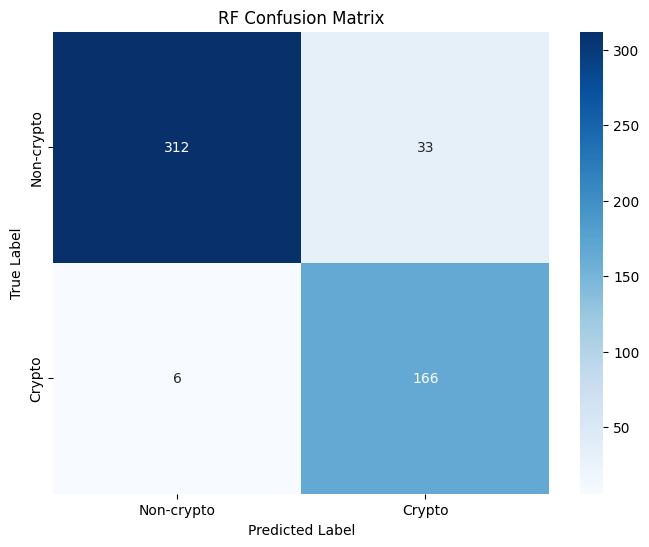

SVM Accuracy: 0.7911
              precision    recall  f1-score   support

      Benign       0.79      0.93      0.86       345
   Malicious       0.79      0.51      0.62       172

    accuracy                           0.79       517
   macro avg       0.79      0.72      0.74       517
weighted avg       0.79      0.79      0.78       517


SVM Confusion Matrix:
[[321  24]
 [ 84  88]]


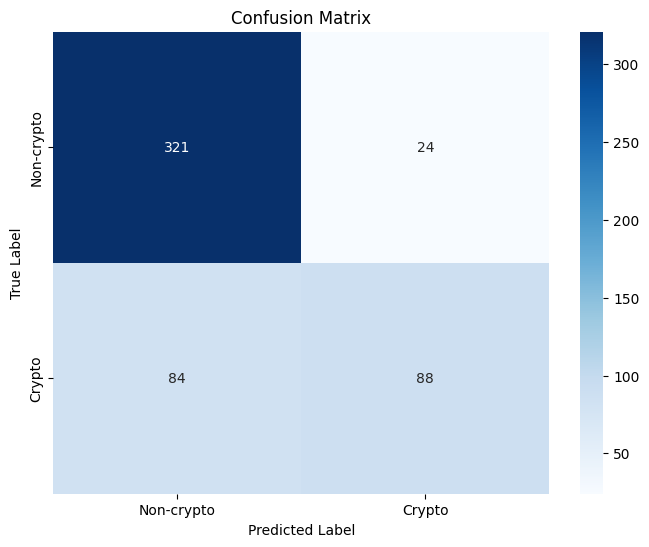

In [16]:
y_pred_rf = rf.predict(X_test_scaled)
print(f"RF Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Benign', 'Malicious']))

# Visualize confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"\nRF Confusion Matrix:")
print(cm_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-crypto', 'Crypto'],
            yticklabels=['Non-crypto', 'Crypto'])
plt.title('RF Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

y_pred_svm = svm.predict(X_test_scaled)
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm, target_names=['Benign', 'Malicious']))

cm_svm = confusion_matrix(y_test, y_pred_svm)
print(f"\nSVM Confusion Matrix:")
print(cm_svm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-crypto', 'Crypto'],
            yticklabels=['Non-crypto', 'Crypto'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


## 9. Feature Importance

In [14]:
print("=" * 60)
print("FEATURE IMPORTANCE")
importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
print(importances.head())

FEATURE IMPORTANCE
        feature  importance
11  packet_rate    0.163705
12    byte_rate    0.159170
5       avg_iat    0.141085
6       std_iat    0.099257
8   burst_ratio    0.081912


## 10. Run Server and Inference

#    Option A: Local monitoring (single machine)
cd monitor && ./app.sh

#    Option B: Distributed monitoring (central server)
#    Doesn't work in our case because we don't have access/permission to grab data from a router.
cd web && ./run.sh